# 01 — Buildings

Everything the Area API knows about buildings is exposed via
`client.buildings.get_area(polygon)`. This notebook covers:

- the `AreaBuildings` return type
- the per-building `DotBimMesh` format
- the per-tile coordinate frame and how building heights are encoded
- a top-down footprint visualisation

In [1]:
from dotenv import load_dotenv
load_dotenv()

from infrared_sdk import InfraredClient
from cities import get

city = get("munich")
print(f"City: {city.name}  ({city.latitude}, {city.longitude})")

City: Munich  (48.1374, 11.5755)


## Fetch the area

`get_area` may transparently issue multiple sub-requests if the polygon
spans more than one server-side tile, then deduplicates and returns one
flat `dict[building_id -> DotBimMesh]`.

In [2]:
with InfraredClient() as client:
    area = client.buildings.get_area(city.polygon_small)

print(f"total_buildings : {area.total_buildings}")
print(f"buildings keys  : {list(area.buildings)[:5]} ...")

total_buildings : 340
buildings keys  : ['5e3638f4-7715-47fe-babb-c197bd6d7fb6', 'e1f12c1a-c5de-4389-955a-a3b8e16cb041', '56316f8b-31db-4319-97a4-c0fe5d4bb849', 'c43c4c56-48b1-4c2f-a93f-34cd9181472a', 'bd715c8e-8da4-4b06-ae15-f75f42bd3ff8'] ...


## Anatomy of a `DotBimMesh`

Each building is an extruded mesh: a flat `[x, y, z, x, y, z, ...]`
coordinate array plus a triangle-index array. The z values encode
building height directly (`max(z) - min(z)`).

In [3]:
import numpy as np

bid, mesh = next(iter(area.buildings.items()))
mesh_dict = mesh.model_dump(by_alias=True)

coords = np.array(mesh_dict["coordinates"], dtype=float).reshape(-1, 3)
indices = np.array(mesh_dict["indices"], dtype=int).reshape(-1, 3)
print(f"building     : {bid}")
print(f"vertices     : {len(coords)}")
print(f"triangles    : {len(indices)}")
print(f"height (m)   : {coords[:, 2].max() - coords[:, 2].min():.2f}")
print(f"footprint x range : [{coords[:, 0].min():.1f}, {coords[:, 0].max():.1f}] m")
print(f"footprint y range : [{coords[:, 1].min():.1f}, {coords[:, 1].max():.1f}] m")

building     : 5e3638f4-7715-47fe-babb-c197bd6d7fb6
vertices     : 114
triangles    : 72
height (m)   : 14.50
footprint x range : [229.1, 384.8] m
footprint y range : [383.5, 418.5] m


## Distribution of heights

Buildings are returned with metric heights in the per-tile coordinate
frame. Plotting a histogram is a quick sanity check that data exists
and looks plausible.

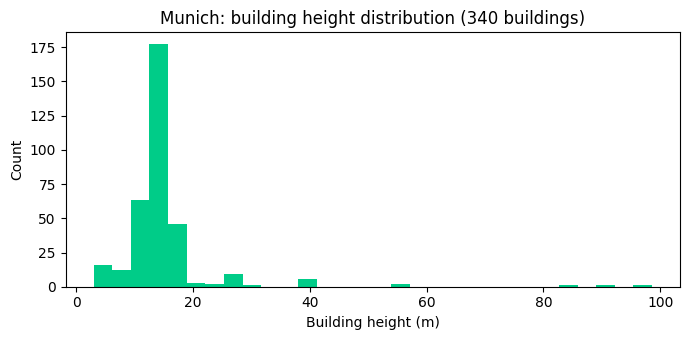

min     : 3.0 m
median  : 15.5 m
max     : 98.6 m


In [4]:
import matplotlib.pyplot as plt

heights = []
for m in area.buildings.values():
    md = m.model_dump(by_alias=True)
    z = np.array(md["coordinates"], dtype=float).reshape(-1, 3)[:, 2]
    heights.append(float(z.max() - z.min()))

plt.figure(figsize=(7, 3.5))
plt.hist(heights, bins=30, color="#0c8")
plt.xlabel("Building height (m)")
plt.ylabel("Count")
plt.title(f"{city.name}: building height distribution ({len(heights)} buildings)")
plt.tight_layout()
plt.show()

print(f"min     : {min(heights):.1f} m")
print(f"median  : {sorted(heights)[len(heights)//2]:.1f} m")
print(f"max     : {max(heights):.1f} m")

## Footprint plot

Each building is a triangulated extruded mesh, so the real footprint is
the union of triangles whose vertices all lie on the bottom face. Drawing
those triangles directly gives a faithful top-down view -- including
L-shaped, U-shaped, and other non-convex buildings.

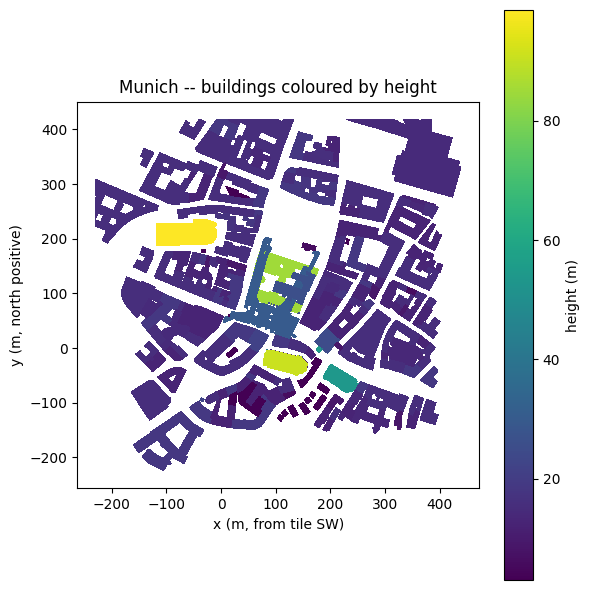

In [5]:
from matplotlib.tri import Triangulation

# DotBim meshes are triangulated. To draw the true footprint shape, we keep
# triangles whose three vertices all sit on the bottom face (z == min) and
# render them directly as a triangulation. This handles non-convex shapes
# correctly -- a polar-angle sort would star-shape any L or U-plan building.
all_xy, all_tris, all_h = [], [], []
offset = 0
for m in area.buildings.values():
    md = m.model_dump(by_alias=True)
    pts = np.array(md["coordinates"], dtype=float).reshape(-1, 3)
    tris = np.array(md["indices"], dtype=int).reshape(-1, 3)
    z = pts[:, 2]
    z_min = z.min()
    bottom = np.isclose(z[tris], z_min, atol=0.05).all(axis=1)
    if not bottom.any():
        continue
    bottom_tris = tris[bottom]
    all_xy.append(pts[:, :2])
    all_tris.append(bottom_tris + offset)
    all_h.append(np.full(len(bottom_tris), z.max() - z_min))
    offset += len(pts)

xy = np.vstack(all_xy)
triangles = np.vstack(all_tris)
hvals = np.concatenate(all_h)
tri = Triangulation(xy[:, 0], xy[:, 1], triangles)

fig, ax = plt.subplots(figsize=(6, 6))
tpc = ax.tripcolor(tri, facecolors=hvals, cmap="viridis",
                   edgecolors="none", shading="flat")
ax.set_aspect("equal")
ax.set_xlabel("x (m, from tile SW)"); ax.set_ylabel("y (m, north positive)")
ax.set_title(f"{city.name} -- buildings coloured by height")
fig.colorbar(tpc, ax=ax, label="height (m)")
plt.tight_layout()
plt.show()

## Notes

- **Coordinate frame.** Coordinates are in **meters relative to the
  tile's SW corner** (x = east, y = north, z = up). For a single-tile
  polygon the tile SW is the polygon's bbox SW.
- **Multi-tile polygons.** Buildings that straddle a tile boundary are
  returned in **all** tiles they touch, with their full (unclipped)
  geometry. The orchestrator handles this for you when you pass
  `area.buildings` to `run_area_and_wait`.
- **DotBim format.** Same schema as the [.bim](https://dotbim.net) format
  used in BIM workflows -- you can export to `.bim` files for use in
  Rhino, Blender, Three.js, etc.

Next: `02_vegetation_and_ground.ipynb` covers trees and surface materials.